In [66]:
from tinyphysics import TinyPhysicsModel, TinyPhysicsSimulator, CONTROL_START_IDX
from controllers import pid, zero, pid_v2, pid_ref
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme()


In [115]:
def plot_rollout(sim:TinyPhysicsSimulator):
  fig, ax = plt.subplots(figsize=(10, 5))
  ax.plot(sim.target_lataccel_history, label="Target Lateral Acceleration", alpha=0.5)
  ax.plot(sim.current_lataccel_history, label="Actual Lateral Acceleration", alpha=0.5)
  ax.legend()
  ax.set_xlabel("Step")
  ax.set_ylabel("Lateral Acceleration")
  ax.set_title("Rollout")
  plt.show()

In [116]:
model = TinyPhysicsModel("./models/tinyphysics.onnx", debug=True)

target_lataccel:  1.0737234709618368
current_lataccel:  1.0685058632530289
state:  State(roll_lataccel=0.3721846564960506, v_ego=33.6662993138583, a_ego=-0.1427389358746498)
future_plan:  FuturePlan(lataccel=[1.0527911761675326, 1.0243747365375606, 0.7800144861106189, 0.7701471502025644, 0.7606936247013875, 0.7675926000293568, 0.7701212729106445, 0.7734588263379781, 0.7746073695177639, 0.768343857412982, 0.7880037662795076, 0.8037960334517689, 0.8074734025781413, 0.8016847911581142, 0.8093308107381891, 0.8309922778751787, 0.8379868484463135, 0.8781050023664648, 0.9350315270915028, 0.9829995984993009, 0.9823740974924196, 0.9805936345655452, 0.9768409063244464, 0.9694934009967991, 0.9593378717353104, 0.9563531205207432, 0.9555821536445844, 0.959805023761181, 0.9401465642115588, 0.936562059691202, 0.9314206330604492, 0.9111837330570666, 0.8744806771807574, 0.8436483842390793, 0.8251624395114685, 0.7475194362244987, 0.7016215909793354, 0.6769279213065456, 0.6503341737796666, 0.570335200530

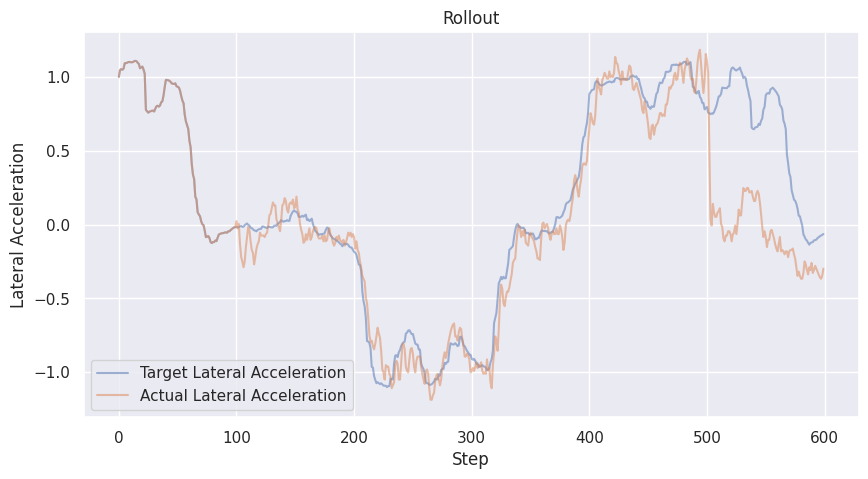

In [150]:
import importlib
importlib.reload(pid_v2)
controller = pid_v2.Controller()
# controller = pid_ref.Controller()
sim = TinyPhysicsSimulator(model, "./data/00000.csv", controller=controller, debug=False)
print(sim.rollout())
plot_rollout(sim)

In [158]:
sim.data.iloc[100]

roll_lataccel      -0.113801
v_ego              33.639615
a_ego               0.043365
target_lataccel    -0.017637
steer_command            NaN
Name: 100, dtype: float64

In [164]:
sim.get_state_target_futureplan(100)[2].lataccel.__len__()

49

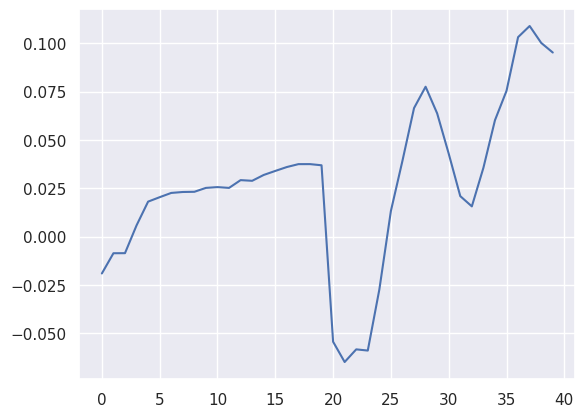

In [151]:
cmds = sim.action_history
plt.plot(cmds[80:120])